# Yamamoto et al. (2020) — reproducing Figure 7

Paper: *A search for a contribution from axion-like particles to the X-ray diffuse background utilizing the
Earth's magnetic field*, JCAP 02 (2020) 011 ([arXiv:1906.04429](https://arxiv.org/abs/1906.04429), local copy in
[docs/](docs/)).

The figure plots the axion-photon coupling `g_agg` against the axion mass `m_a`. Everything except the two Suzaku
regions is taken from Ciaran O'Hare's [AxionLimits](https://cajohare.github.io/AxionLimits/) archive; the Suzaku
regions are computed here from the paper's own equations.

| Colour in Fig. 7 | What it is | Where it comes from |
|---|---|---|
| grey | CAST | `CAST.txt` + `CAST_highm.txt` |
| red | ADMX, plus the old RBF/UF haloscopes | `ADMX.txt` + `RBF_UF_Haloscopes.txt` |
| blue line | ADMX projected reach | `Projections/ADMX_Projected.txt` |
| magenta line | IAXO projected reach | `Projections/IAXO.txt` |
| green | QCD axion model band | formula, see below |
| yellow | Suzaku, universal continuous ALP | **this paper**, eq. (4.1) |
| cyan | Suzaku, galactic monochromatic ALP | **this paper**, eqs. (4.3) and (2.10) |

## How to read the plot

Three different kinds of statement share one pair of axes, and the drawing style is what tells them apart.

**Filled regions are exclusions.** An experiment looked, saw nothing, and therefore ruled out every coupling
*above* its curve (at 99% confidence, for the Suzaku ones). A larger coupling would have produced a bigger signal,
so a null result rules out large couplings and says nothing about small ones. That is why every filled region
extends upwards off the top of the frame, and why none of them has a lower edge.

**Lines are projected sensitivity.** IAXO and "ADMX prospects" have not excluded anything. They mark the reach an
experiment expects to achieve — in IAXO's case with hardware that does not exist yet. Do not read them as limits.

**The green band is a prediction, not a measurement.** For a genuine QCD axion the coupling is not free: it is
tied to the mass, so any one model is a *line*, not a band. The band is just the envelope of those lines as you
vary the model. It is not an uncertainty, and it is not a floor — an axion-like particle (ALP), which is what
this paper constrains, has independent mass and coupling and can sit anywhere on the plane, including below the
band. The useful question is whether any exclusion region has reached *down* to the band. On this figure, none
has: the Suzaku limits sit about four orders of magnitude above it.

Both axes are logarithmic, spanning nine decades in mass and eleven in coupling.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from darknessalp import fetch_axion_limit


def axionlimits(name):
    """Return (m_a [eV], g_agg [GeV^-1]) from the cached AxionLimits archive."""
    m, g = fetch_axion_limit(name.replace("/", "_"))
    return np.asarray(m), np.asarray(g)


for f in ["CAST.txt", "CAST_highm.txt", "ADMX.txt", "RBF_UF_Haloscopes.txt",
          "Projections/ADMX_Projected.txt", "Projections/IAXO.txt"]:
    axionlimits(f)

## The two Suzaku limits

These are not in AxionLimits — the paper is the only source, so they are computed here from its equations.

### Yellow: universal continuous ALP, eq. (4.1)

Evaluated at the paper's reference values (dark matter mass 10 keV, lifetime $4.32 \times 10^{17}$ s,
$B_\perp L = 100$ T m, density 1.25 keV cm$^{-3}$, $H_0 = 67.8$), eq. (4.1) is a flat bound:

$$
g_{a\gamma\gamma} < 3.3 \times 10^{-7}\ \mathrm{GeV^{-1}}
$$

It only holds while the conversion stays coherent, which eq. (2.12) puts at

$$
m_a < \sqrt{\frac{2\pi E_a}{L}} \simeq 3.3 \times 10^{-6}\ \mathrm{eV}
$$

A flat bound plus a hard cutoff is why the yellow region is a plain rectangle.

### Cyan: galactic monochromatic ALP, eqs. (4.3) and (2.10)

Eq. (4.3) gives a flat bound of $8.4 \times 10^{-8}\ \mathrm{GeV^{-1}}$, but instead of cutting it off abruptly the
paper keeps the full conversion probability of eq. (2.10):

$$
P_{a \to \gamma} = \left( \frac{g_{a\gamma\gamma} B_\perp L}{2} \right)^{2} R(qL)
$$

$$
R(x) = \frac{2\,[1 - \cos x]}{x^{2}}, \qquad q = \frac{m_a^{2}}{2 E_a}
$$

Here $qL$ measures how many oscillation lengths fit inside the magnetic field region. While $qL \ll 1$ the
conversion is coherent and $R \to 1$; once $qL$ grows past 1 the amplitude starts cancelling against itself, the
experiment loses sensitivity, and the bound weakens. Since a weaker conversion needs a larger coupling to give
the same signal, the excluded boundary is

$$
g_{a\gamma\gamma}(m_a) = \frac{8.4 \times 10^{-8}\ \mathrm{GeV^{-1}}}{\sqrt{R(qL)}}
$$

which is flat at small mass and turns upwards as $m_a^{2}$ once coherence is lost. That is the cyan curve's knee.

### Two things measured off the published figure

The paper does not give enough numbers to draw the cyan curve from the text alone, so its own figure was
digitised: the PDF page was rasterised at 400 dpi, each coloured region extracted, and the axes calibrated from
the frame corners. The calibration recovers the paper's quoted values to a few percent (yellow
$3.32 \times 10^{-7}$ vs $3.3 \times 10^{-7}$; cyan $8.36 \times 10^{-8}$ vs $8.4 \times 10^{-8}$), so the
readings below are trustworthy.

**1. The published curve is smooth, so it must be the oscillation-averaged envelope.**
Taken literally, $R(x)$ hits zero whenever $x = 2\pi n$, where the bound diverges. Plotting that puts a comb of
thin unexcluded slivers through the cyan region, and the published figure has none. Averaging the oscillation
away, meaning $\langle 1 - \cos x \rangle \to 1$, gives the smooth envelope

$$
R = \frac{2}{2 + x^{2}} \qquad \Longrightarrow \qquad
g_{a\gamma\gamma} = g_{0} \sqrt{1 + \frac{(qL)^{2}}{2}}
$$

which matches the measured boundary to 4% on average over two decades of mass. The literal version is off by up
to 490%. So the envelope is what was drawn. `SMOOTH_OSCILLATION` switches between the two.

**2. The knee sits at $1.26 \times 10^{-5}$ eV, not at the $3.3 \times 10^{-6}$ eV quoted in the text.**
Fitting $qL = \pi (m_a / m_\mathrm{coh})^{2}$ to the measured rise gives $m_\mathrm{coh} = 1.26 \times 10^{-5}$ eV.
Since $m_\mathrm{coh} = \sqrt{2 \pi E_a / L}$, that corresponds to a path length $L$ of roughly 4 to 9 Earth radii
for 3.5 to 7 keV photons — which is exactly the region over which the paper says it integrated the geomagnetic
field ("up to 6 times the Earth's radius"). The $3.3 \times 10^{-6}$ eV in the text would instead need $L$ of
35 to 100 Earth radii. So the figure is self-consistent with the stated geometry and the text's number is the
odd one out. `M_COH_GAL` is set from the figure and left as a knob.

If you run your own analysis, do not inherit this number: compute $m_\mathrm{coh} = \sqrt{2 \pi E_a / L}$ from
your own line-of-sight path and photon energy.

In [2]:
# ---- from the paper's text -------------------------------------------------
G_UNIVERSAL = 3.3e-7    # GeV^-1, eq. (4.1)          [figure: 3.32e-7]
G_GALACTIC = 8.4e-8     # GeV^-1, eq. (4.3)          [figure: 8.36e-8]
M_COH_UNI = 3.3e-6      # eV, coherence mass of eq. (2.12), cuts off the yellow box

# ---- fitted to the published cyan curve (see above) ------------------------
M_COH_GAL = 1.26e-5     # eV, mass at which qL = pi for the galactic curve
SMOOTH_OSCILLATION = True   # True  -> <1-cos x> = 1 envelope, as published
                            # False -> literal eq. (2.10), spikes and all


def g_galactic(m_a):
    """Eq. (4.3) with the eq. (2.10) oscillation factor: g(m) = g0 / sqrt(R(qL))."""
    x = np.pi * (m_a / M_COH_GAL) ** 2                      # qL
    if SMOOTH_OSCILLATION:
        return G_GALACTIC * np.sqrt(1 + x ** 2 / 2)          # R = 2/(2+x^2)
    R = np.where(x < 1e-4, 1 - x ** 2 / 12, 2 * (1 - np.cos(x)) / x ** 2)
    return G_GALACTIC / np.sqrt(np.clip(R, 1e-300, None))


# what path length L does each coherence mass imply, at E_a = 4 keV?
M_TO_INV_EV = 5.06773e6                                      # 1 m expressed in eV^-1
R_EARTH = 6.371e6                                            # m
for label, mc in [("yellow (text)", M_COH_UNI), ("cyan (figure)", M_COH_GAL)]:
    L = 2 * np.pi * 4e3 / mc ** 2 / M_TO_INV_EV
    print(f"{label:15s} m_coh={mc:.2e} eV -> L={L:.2e} m = {L/R_EARTH:5.1f} Earth radii")

yellow (text)   m_coh=3.30e-06 eV -> L=4.55e+08 m =  71.5 Earth radii
cyan (figure)   m_coh=1.26e-05 eV -> L=3.12e+07 m =   4.9 Earth radii


## Matching the published figure's other choices

The paper's non-Suzaku curves were digitised from a 2013 review and CAST 2017; AxionLimits ships today's
compilation of the same experiments. Three differences follow, all switchable with `MATCH_PAPER`.

**Red is two blocks, not one.** The figure shows ADMX at 1.7 to 3.2 µeV and a second block at 4.2 to 16 µeV.
That second block is the old RBF and UF haloscopes from the 1980s, drawn in the same colour. Loading
`RBF_UF_Haloscopes.txt` alongside `ADMX.txt` reproduces it. One honest leftover: the archive has a real gap in
coverage near 11 µeV, which shows here as a white slot the paper's coarser digitisation drew straight through.

**The QCD band is wider and lower than the AxionLimits default.** The band is drawn as
$g_{a\gamma\gamma} = 2 \times 10^{-10}\, C_{a\gamma}\, m_a$, with $C_{a\gamma}$ swept over a range of models.
AxionLimits uses $C_{a\gamma}$ from 0.25 to 12.75; the published band measures 0.069 to 7.75. Note this is a
convention fitted to their picture — for your own work, use the AxionLimits range and say which you used.

**CAST stops at 1.63 eV in the figure.** Today's `CAST_highm.txt` carries newer high-mass runs out to 190 eV, so
left alone the grey floods the top-right corner. Clipping it reproduces the published look, but be careful: the
clip paints "not excluded" over parameter space that current data *does* exclude. Correct for a 2020 replica,
wrong for anything you publish yourself.

One difference that cannot be dialled out, only noted: the paper's ADMX-prospects outline runs from
$1.4 \times 10^{-6}$ to $2.1 \times 10^{-5}$ eV, whereas today's projection file runs from
$7.3 \times 10^{-7}$ to $1.1 \times 10^{-4}$ eV. `CLIP_PROJECTION` trims the right end; the left leg stays put.

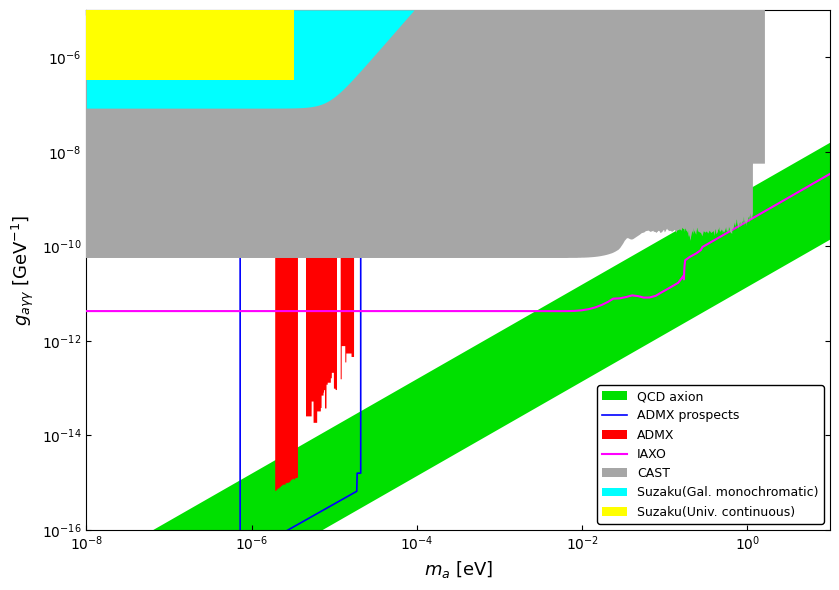

In [3]:
MATCH_PAPER = True

C_BAND = (0.069, 7.75) if MATCH_PAPER else (abs(5/3 - 1.92), 44/3 - 1.92)
CAST_MAX_MASS = 1.63 if MATCH_PAPER else np.inf       # eV, where the figure's grey ends
CLIP_PROJECTION = 2.09e-5 if MATCH_PAPER else np.inf  # eV, right leg of the blue outline

XLIM = (1e-8, 1e1)      # m_a  [eV]
YLIM = (1e-16, 1e-5)    # g_agg [GeV^-1]   (the figure's frame top is 9.6e-6)
TOP = YLIM[1]


def clip_right(m, g, mmax, close_to=TOP):
    """Cut a boundary/outline at mmax and close it with a vertical leg."""
    if not np.isfinite(mmax) or m.max() <= mmax:
        return m, g
    keep = m <= mmax
    return np.append(m[keep], [mmax, mmax]), np.append(g[keep], [g[keep][-1], close_to])


fig, ax = plt.subplots(figsize=(8.5, 6.0))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)

# --- QCD axion model band (a formula, not a data file) ----------------------
mm = np.array([1e-30, 1e20])
ax.fill_between(mm, 2e-10 * C_BAND[0] * mm, 2e-10 * C_BAND[1] * mm,
                color="#00e000", lw=0, zorder=0, label="QCD axion")

# --- projected reach: drawn as lines, since nothing is excluded yet ---------
m, g = axionlimits("Projections/ADMX_Projected.txt")
m, g = clip_right(m, g, CLIP_PROJECTION)
ax.plot(m, g, "-", color="blue", lw=1.2, zorder=1, label="ADMX prospects")

# --- haloscopes: ADMX proper + the RBF/UF block the paper draws in red ------
for i, f in enumerate(["ADMX.txt", "RBF_UF_Haloscopes.txt"]):
    m, g = axionlimits(f)
    ax.fill_between(m, g, TOP, color="red", lw=0, zorder=2,
                    label="ADMX" if i == 0 else None)

m, g = axionlimits("Projections/IAXO.txt")
ax.plot(m, g, "-", color="magenta", lw=1.5, zorder=3, label="IAXO")

# --- CAST -------------------------------------------------------------------
for i, f in enumerate(["CAST.txt", "CAST_highm.txt"]):
    m, g = clip_right(*axionlimits(f), CAST_MAX_MASS)
    ax.fill_between(m, g, TOP, color="0.65", lw=0, zorder=4,
                    label="CAST" if i == 0 else None)

# --- this paper -------------------------------------------------------------
m = np.logspace(np.log10(XLIM[0]), np.log10(XLIM[1]), 400_000)
g_gal = g_galactic(m)
ax.fill_between(m, np.minimum(g_gal, TOP), TOP, where=g_gal < TOP,
                color="cyan", lw=0, zorder=5, label="Suzaku(Gal. monochromatic)")
ax.fill_between([XLIM[0], M_COH_UNI], G_UNIVERSAL, TOP,
                color="yellow", lw=0, zorder=6, label="Suzaku(Univ. continuous)")

# --- cosmetics --------------------------------------------------------------
ax.set_xlabel(r"$m_a$ [eV]", fontsize=13)
ax.set_ylabel(r"$g_{a\gamma\gamma}$ [GeV$^{-1}$]", fontsize=13)
ax.tick_params(which="both", direction="in", top=True, right=True)

order = ["QCD axion", "ADMX prospects", "ADMX", "IAXO", "CAST",
         "Suzaku(Gal. monochromatic)", "Suzaku(Univ. continuous)"]
h, l = ax.get_legend_handles_labels()
by_label = dict(zip(l, h))
ax.legend([by_label[k] for k in order], order, loc="lower right",
          fontsize=9, framealpha=1, edgecolor="k")

fig.tight_layout()
fig.savefig("../outputs/Yamamoto2020_Fig7.png", dpi=200)
plt.show()

## Knobs

| Constant | Effect |
|---|---|
| `MATCH_PAPER` | `False` gives today's AxionLimits data with its own conventions: grey out to 190 eV, narrower green band, full ADMX projection |
| `SMOOTH_OSCILLATION` | `False` gives literal eq. (2.10), showing the unexcluded slivers that the published envelope hides |
| `M_COH_GAL` | where the cyan knee sits. 1.26e-5 eV reproduces the figure; 3.3e-6 eV is what the text's coherence condition would give |
| `G_UNIVERSAL`, `G_GALACTIC` | the two 99% confidence bounds. Replace these with your own Suzaku fit — table 3 of the paper gives the per-field surface-brightness limits that feed eq. (4.1) |

### What is real data and what is not

Worth being clear about, since the figure mixes them:

* **Real archive files, plotted unmodified:** CAST, ADMX, RBF/UF, the ADMX projection, IAXO.
* **A formula, not a data file:** the green band. AxionLimits draws it the same way, in code.
* **Computed from the paper's equations:** the yellow and cyan regions.
* **Cosmetic truncations of real data:** the CAST and projection clips, closed off with a vertical leg. Both are
  off when `MATCH_PAPER = False`.